# Constructing and Testing Scraper Pipelines

Use this notebook to _create_, _test_, and _validate_ each particular scraping function (for each data source). The final functions will be added as methods to the _EventScraper_ class.

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import requests
import json

# import scraping packages and libraries
from selenium import webdriver
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from camoufox.sync_api import Camoufox
import undetected_chromedriver as uc
from bs4 import BeautifulSoup
from scrapy import Selector
import pyperclip
# Optional TLS impersonation fallback library
try:
    from curl_cffi import requests as tls_requests
except ImportError:
    import requests as tls_requests

# import supporting packages for system interactions
import random
import time
import os
import re

# import support for geocoding
from geopy.geocoders import Nominatim

# import support for classifier model
from transformers import pipeline
from pydantic import BaseModel
from typing import Literal
import ollama

In [2]:
# set start time
start = time.perf_counter()

## Create Supporting Functions

In [3]:
# create helper function to use selenium for dynamically rendered pages
def dismiss_modal_if_present(driver) -> bool:
    """
    Checks for lightbox/dialog close buttons or banner overlays.
    Uses a single multi-selector check without blocking delays.
    """
    close_selectors = [
        "a.dialog-close-button",
        "a[aria-label='Close']",
        ".dialog-lightbox-close-button",
        "button.close",
        "[aria-label='Close modal']",
        ".modal-close"
    ]
    
    combined_selector = ", ".join(close_selectors)
    
    try:
        # Fast non-blocking DOM search
        close_btns = driver.find_elements(By.CSS_SELECTOR, combined_selector)
        for btn in close_btns:
            if btn.is_displayed():
                try:
                    btn.click()
                    print("[Banner Handler] Closed banner via click.")
                    time.sleep(0.5)
                    return True
                except Exception:
                    driver.execute_script("arguments[0].click();", btn)
                    print("[Banner Handler] Closed banner via JS click.")
                    time.sleep(0.5)
                    return True
    except Exception:
        pass

    # Keyboard ESC fallback
    try:
        driver.find_element(By.TAG_NAME, "body").send_keys(Keys.ESCAPE)
    except Exception:
        pass

    return False

# ====================================================
# retry the scrape when a CAPTCHA is encountered
def wait_for_cloudflare_pass(driver, max_wait: int = 15) -> bool:
    """
    Polls the driver until Cloudflare challenge keywords disappear from the page title and DOM.
    Returns True if passed, False if still blocked after timeout.
    """
    challenge_keywords = [
        "robot challenge",
        "checking the site connection",
        "just a moment",
        "attention required",
        "verify you are human",
        "cloudflare"
    ]
    
    start_time = time.time()
    while time.time() - start_time < max_wait:
        title = driver.title.lower() if driver.title else ""
        
        # Check if title still indicates a challenge
        in_challenge_title = any(kw in title for kw in ["just a moment", "challenge", "checking your browser"])
        
        if not in_challenge_title:
            # Check page source text for challenge indicators
            try:
                page_text = driver.find_element(By.TAG_NAME, "body").text.lower()
            except Exception:
                page_text = ""

            in_challenge_body = any(kw in page_text for kw in ["checking the site connection security", "robot challenge screen"])
            
            # If neither title nor body shows challenge keywords, we've passed!
            if not in_challenge_body:
                return True

        # Brief sleep between polls
        time.sleep(1)

    print(f"[Cloudflare Handler] Timed out after {max_wait} seconds waiting for challenge pass.")
    return False

# ====================================================
# use multiple paths to attempt a page data collection
def fetch_rendered_html(url: str, wait_for_selector: str = None, timeout: int = 15) -> BeautifulSoup:
    soup = None

    # --- ATTEMPT 1: Standard Selenium (Non-Headless) ---
    options = Options()
    options.add_argument("--start-maximized")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-blink-features=AutomationControlled")

    driver = None
    try:
        driver = webdriver.Chrome(options=options)
        
        # Mask navigator.webdriver flag
        driver.execute_cdp_cmd(
            "Page.addScriptToEvaluateOnNewDocument",
            {"source": "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"}
        )
        
        driver.get(url)

        # 1. First, wait for Cloudflare Challenge screen to auto-resolve
        wait_for_cloudflare_pass(driver, max_wait=12)

        # 2. Wait for target selector if specified
        if wait_for_selector:
            try:
                WebDriverWait(driver, timeout).until(
                    EC.presence_of_element_located((By.CSS_SELECTOR, wait_for_selector))
                )
            except Exception:
                pass
        else:
            time.sleep(2)

        dismiss_modal_if_present(driver)
        soup = BeautifulSoup(driver.page_source, "html.parser")

    except Exception as e:
        print(f"[Selenium] Error: {e}")
    finally:
        if driver:
            try:
                driver.quit()
            except Exception:
                pass

    # Verify content validity
    page_text = soup.get_text().lower() if soup else ""
    is_blocked = any(
        phrase in page_text 
        for phrase in ["robot challenge", "checking the site connection", "just a moment", "attention required"]
    )
    has_target = soup.select_one(wait_for_selector) if (soup and wait_for_selector) else True

    if soup and not is_blocked and has_target:
        return soup

    # --- ATTEMPT 2: Undetected Chromedriver (Non-Headless) ---
    print(f"[Fallback] Retrying {url} with undetected-chromedriver...")
    uc_driver = None
    try:
        uc_options = uc.ChromeOptions()
        uc_options.add_argument("--start-maximized")
        uc_options.add_argument("--window-size=1920,1080")

        uc_driver = uc.Chrome(options=uc_options)
        uc_driver.get(url)

        # Wait for Cloudflare Challenge to pass under UC
        wait_for_cloudflare_pass(uc_driver, max_wait=12)

        if wait_for_selector:
            try:
                WebDriverWait(uc_driver, timeout).until(
                    EC.presence_of_element_located((By.CSS_SELECTOR, wait_for_selector))
                )
            except Exception:
                pass
        else:
            time.sleep(2)

        dismiss_modal_if_present(uc_driver)
        soup = BeautifulSoup(uc_driver.page_source, "html.parser")
        return soup

    except Exception as e:
        print(f"[UC Fallback] UC failed: {e}")
    finally:
        if uc_driver:
            try:
                uc_driver.quit()
            except Exception:
                pass

    return soup
# ====================================================
# use the US census API to get latitude and longitude
def get_census_coordinates(address_string):
    """
    Takes a full address string (e.g. "1600 Pennsylvania Ave NW, Washington, DC 20006")
    and returns (latitude, longitude) or (None, None) if not found.
    """
    if not address_string or pd.isna(address_string):
        return None, None
        
    url = "https://geocoding.geo.census.gov/geocoder/locations/onelineaddress"
    params = {
        "address": address_string,
        "benchmark": "Public_AR_Current",
        "format": "json"
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        
        matches = data.get("result", {}).get("addressMatches", [])
        if matches:
            # Extract coordinates (Census API returns x=longitude, y=latitude)
            coordinates = matches[0]["coordinates"]
            return coordinates["y"], coordinates["x"]  # Latitude, Longitude
    except:
        # try using geopy instead
        try:
            geolocator = Nominatim(user_agent="vivida_app")
            location = geolocator.geocode(address_string)

            # define the lat and long
            return location.latitude, location.longitude
        except Exception as e:
            print(f"Geocoding failed for '{address_string}': {e}")
        
    return None, None

# ====================================================
# conceptual Zero-Shot Ingestion Structure
# 1. Initialize the classifier ONCE globally (outside the row loop/function)
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Define spectrum maps with label -> coordinate value
NOVELTY_SPECTRUM = {
    "traditional, conventional, classic, landmark": 0.1,
    "familiar, mainstream, popular, fresh": 0.35,
    "niche, specialized, alternative, eclectic": 0.70,
    "exotic, experimental, avant-garde, unconventional": 0.95
}

SOCIAL_SPECTRUM = {
    "solitary, introspective, secluded, independent": 0.1,
    "intimate, conversational, cozy, small-group": 0.35,
    "communal, interactive, social, outgoing": 0.70,
    "packed, festive, high-capacity, party-oriented": 0.95
}

ENERGY_SPECTRUM = {
    "restorative, stationary, serene, sedentary": 0.1,
    "leisurely, relaxed, seated, low-key": 0.35,
    "lively, animated, bustling, dynamic": 0.70,
    "intense, high-octane, rigorous, exhilarating": 0.95
}

# Pre-combine candidate labels for a single unified forward pass
ALL_CANDIDATES = (
    list(NOVELTY_SPECTRUM.keys()) + 
    list(SOCIAL_SPECTRUM.keys()) + 
    list(ENERGY_SPECTRUM.keys())
)

# ====================================================
# initial classifier, using zero-start model
def mood_classifier(desc: str) -> list:
    if not desc or len(desc.strip()) < 10:
        return [0.5, 0.5, 0.5]  # Default neutral values for empty descriptions

    # Single pass across all 12 spectrum anchors simultaneously
    result = classifier(
        desc, 
        candidate_labels=ALL_CANDIDATES,
        multi_label=True  # Allows independent scoring across dimensions
    )

    # Convert returned arrays to a lookup dictionary: {label_string: softmax_score}
    score_map = dict(zip(result['labels'], result['scores']))

    # Compute weighted averages per dimension
    novelty_score = round(
        sum(score_map[lbl] * val for lbl, val in NOVELTY_SPECTRUM.items()), 4
    )
    social_score = round(
        sum(score_map[lbl] * val for lbl, val in SOCIAL_SPECTRUM.items()), 4
    )
    energy_score = round(
        sum(score_map[lbl] * val for lbl, val in ENERGY_SPECTRUM.items()), 4
    )

    return [novelty_score, social_score, energy_score]

# ====================================================
# scraping function for expanded descriptions
def fetch_event_text(soup):
    try:
        # Remove clutter scripts, styles, and navigation elements
        for element in soup(["script", "style", "nav", "header", "footer", "aside", "svg", "iframe"]):
            element.decompose()
            
        # Get clean inner text
        text = soup.get_text(separator='\n', strip=True)
        # print(text)
        patterns = [
        r"Cookie Policy.*",
        r"All rights reserved.*",
        r"Subscribe to our newsletter.*",
        r"Skip to content",
        ]
        for pattern in patterns:
            text = re.sub(pattern, "", text, flags=re.IGNORECASE)
        return text.strip()
    except Exception as e:
        print(f"expanded description unavailable: {e}")
        return None

# ====================================================
# normalize the mood vector scores
def normalize_score(raw_scores):
    """Scales a raw score bounded by anchor limits to a continuous [0.0, 1.0] range."""
    # compute the robust normalization
    med = np.median(raw_scores)
    q2 = np.quantile(raw_scores, 0.25)
    q4 = np.quantile(raw_scores, 0.75)
    iqr = q4-q2

    # compute the robust normalization
    robust = [round((x-med)/iqr,4) for x in raw_scores]
    
    return robust

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

## Tacoma Dome

---

In [4]:
# set the head url as the link value
link = "https://www.tacomadome.org/events"

# set the venue location as the default location for the events
location = "2727 E D St, Tacoma, WA 98421"

# get the HTML content of the page
response = requests.get(link)
soup = BeautifulSoup(response.content, 'html.parser')

# filter to only the section of interest, which is the table containing the data we want to extract
target_table = soup.find("div", class_="full_column non-widget-area") # IMPORTANT: this is the div that contains the table we want to extract

# strip out unnecessary scripts and styles
for script in target_table(["script", "style"]):
    script.decompose()

# find all blocks where the class has the pattern r"eventItem
pat = re.compile(r"^eventItem.*clearfix$")

# find all divs with the class that matches the pattern
event_items = target_table.find_all(class_=pat)

# create a dictionary to hold the event data
event_dict = {}
td_df = pd.DataFrame()

# parse each event to get name, link to details, date (range), description, image link, location, price, and ticket link (if available)
for event in event_items:
    # get the name of the event
    try:
        event_dict["title"] = event.find("h3").get_text(strip=True)
    except AttributeError:
        event_dict["title"] = None

    # get the link to the details page
    try:
        event_dict["external_url"] = event.find("a")["href"]
    except AttributeError:
        event_dict["external_url"] = None

    # get the date range of the event
    try:
        event_dict["start_time"] = event.find("div", class_="date").get("aria-label").strip()
    except AttributeError:
        event_dict["start_time"] = None

    # get the description of the event
    try:
        event_dict["description"] = event.find("h4").get_text(strip=True)
    except AttributeError:
        event_dict["description"] = None

    # get the image link of the event
    try:
        event_dict["image_url"] = event.find("div", class_="background-img").get("style") 
    except AttributeError:
        event_dict["image_url"] = None
        
    # get the ticket link of the event (if available)
    try:
        event_dict["ticket_link"] = event.find("a", class_="tickets onsalenow").get("href").strip()
    except AttributeError:
        event_dict["ticket_link"] = None

    # use async function to get expanded descriptions
    try:
        response = requests.get(event_dict["external_url"])
        event_dict["big_desc"] = fetch_event_text(BeautifulSoup(response.content, 'html.parser'))
    except Exception as e:
        event_dict["big_desc"] = None

    # concatenate the event_dict to the dataframe
    td_df = pd.concat([td_df, pd.DataFrame([event_dict])], ignore_index=True)

# add the location and location link to the dataframe (invariant for all events at the Tacoma Dome)
td_df["address"] = location
td_df["venue_name"] = "Tacoma Dome"

# reset the index
td_df = td_df.reset_index(drop=True)

# strip away the decorator characters from the TD image url
td_df["image_url"] = td_df["image_url"].apply(lambda x : str(x)[22:-2])

# convert start_time to arrays of dt objects
td_df[["first_day", "last_day"]] = (
    td_df["start_time"].str.split(" to ", expand=True).apply(lambda col: col.str.strip())
)

# Extract year from last_day (\b\d{4}\b matches exact 4-digit year boundaries)
extracted_year = td_df["last_day"].str.extract(r"(\b\d{4}\b)", expand=False)

# Boolean mask: has first_day, missing a year in first_day, and has a year in last_day
needs_year = (
    extracted_year.notna()
)

# Apply update in-place
td_df.loc[needs_year, "first_day"] = (
    td_df.loc[needs_year, "first_day"].str.strip() + " " + extracted_year[needs_year]
)

# Parse clean pd.Timestamp columns now that both have YYYY
td_df["first_day"] = pd.to_datetime(td_df["first_day"], errors="coerce")
td_df["last_day"]  = pd.to_datetime(td_df["last_day"], errors="coerce")

# Helper function to safely format datetime objects or handle NaT/None
def format_dt(val):
    return val.strftime('%Y-%m-%d') if pd.notna(val) else None

# Corrected list comprehension with ternary 'if/else' BEFORE the 'for' loop
td_df["start_time"] = [
    [format_dt(x), format_dt(y)] if pd.notna(y) else [format_dt(x)]
    for x, y in zip(td_df["first_day"], td_df["last_day"])
]

# drop the helper columns
td_df = td_df.drop(columns=["first_day", "last_day"])

## Emerald Queen

---

In [5]:
# set the head url as the link value
link = "https://emeraldqueen.com/tickets/"

# set the venue location as the default location for the events
location = "2920 E R St, Tacoma, WA 98404"

# get the HTML content of the page
response = requests.get(link)
soup = BeautifulSoup(response.content, 'html.parser')

# filter to only the section of interest, which is the table containing the data we want to extract
target_table = soup.find("section", class_="content page-925 moto-section") # IMPORTANT: this is the div that contains the table we want to extract

# find all divs with the class that matches the pattern
event_items = target_table.find_all("div", class_="moto-widget moto-widget-row moto-spacing-top-medium moto-spacing-right-auto moto-spacing-bottom-medium moto-spacing-left-auto")

# create a dictionary to hold the event data
event_dict = {}
eqc_df = pd.DataFrame()

# parse each event to get name, link to details, date (range), description, image link, location, price, and ticket link (if available)
for event in event_items:
    # batch extract primary details
    try:
        details = event.find_all("div", class_="moto-widget-text-content moto-widget-text-editable")
        # extract the name, date range, and description from the details
        event_dict["title"] = details[0].get_text(strip=True)
        event_dict["start_time"] = details[1].get_text(strip=True)
        event_dict["description"] = details[2].get_text(strip=True)
    except:
        event_dict["title"] = None
        event_dict["start_time"] = None
        event_dict["description"] = None

    # get the link to the details page
    try:
        event_dict["external_url"] = "https://emeraldqueen.com" + event.find("a")["href"]
    except:
        event_dict["external_url"] = None

    # get the image link of the event
    try:
        event_dict["image_url"] = "https://emeraldqueen.com" + event.find("img").get("data-src")
    except:
        event_dict["image_url"] = None

    # follow the details link to get richer details
    details_response = requests.get(event_dict["external_url"])
    details_soup = BeautifulSoup(details_response.content, 'html.parser')
        
    # get the ticket link of the event (if available)
    try:
        event_dict["ticket_link"] = details_soup.find("a", href=re.compile(r"ticketmaster", re.IGNORECASE)).get("href")
    except:
        event_dict["ticket_link"] = None
        
    # use async function to get expanded descriptions
    try:
        response = requests.get(event_dict["external_url"])
        event_dict["big_desc"] = fetch_event_text(BeautifulSoup(response.content, 'html.parser'))
    except Exception as e:
        event_dict["big_desc"] = None

    # concatenate the event_dict to the dataframe
    eqc_df = pd.concat([eqc_df, pd.DataFrame([event_dict])], ignore_index=True)

# add the location and location link to the dataframe (invariant for all events at the Tacoma Dome)
eqc_df["address"] = location
eqc_df["venue_name"] = "Emerald Queen Casino"

# format the data as a datetime object
eqc_df["start_time"] = [[x.strftime('%Y-%m-%d')] for x in pd.to_datetime(eqc_df["start_time"].str.replace('•', ''), format='mixed', errors='coerce')]

# reset the index
eqc_df = eqc_df.reset_index(drop=True)

## Puyallup Fairgrounds

---

In [6]:
# set the link value
link = "https://www.thefair.com/events-calendar/"

# set the venue location as the default location for the events
location = "110 9th Ave SW, Puyallup, WA 98371"

# create a final dataframe to hold all pages' worth of data
final_df = pd.DataFrame()

# iterate through the pages of the events calendar and extract the event data
for page in range(1, 10): # adjust the range as needed to scrape more pages
    # get html from a dynamically rendered page
    try:
        soup = fetch_rendered_html(url=link + f"?page={page}")
    except Exception as e:
        print(f"Error fetching page {page}: {e}")
        break  # Stop the loop if there's an error fetching the page

    # filter to only the section of interest, which is the table containing the data we want to extract
    target_table = soup.find("div", class_="container container--md2") # IMPORTANT: this is the div that contains the table we want to extract

    # find all divs with the class that matches the pattern
    event_items = target_table.find_all("div", class_="event-card-large")
    # create a dictionary to hold the event data
    event_dict = {}
    puy_df = pd.DataFrame()

    # parse each event to get name, link to details, date (range), description, image link, location, price, and ticket link (if available)
    for event in event_items:
        # get name of event
        name_info = event.find("h3")
        try:
            event_dict["title"] = name_info.get_text(strip=True)
        except:
            event_dict["title"] = None

        # get the date range of the event
        try:
            event_dict["start_time"] = event.find("div", class_="icon-text").get_text(strip=True)
        except:
            event_dict["start_time"] = None

        # get the link to the details page
        try:
            event_dict["external_url"] = "https://www.thefair.com" + name_info.find("a")["href"]
        except:
            event_dict["external_url"] = None

        # get the image link of the event
        try:
            event_dict["image_url"] = event.find("img").get("src")
        except:
            event_dict["image_url"] = None
            
        # get the ticket link of the event (if available)
        try:
            event_dict["ticket_link"] = event.find("div", class_="event-card-large__buttons").find("a", href=re.compile(r"ticket")).get("href").strip()
        except:
            try:
                detail_soup = fetch_rendered_html(url=event_dict["details_link"])
                event_dict["ticket_link"] = detail_soup.find("a", href=re.compile(r"ticket")).get("href").strip()
            except:
                event_dict["ticket_link"] = None

        # get the event description
        try:
            event_dict["description"] = event.find("span").get_text(strip=True)
        except:
            event_dict["description"] = None

        # use async function to get expanded descriptions
        try:
            event_dict["big_desc"] = fetch_event_text(fetch_rendered_html(event_dict["external_url"]))
        except Exception as e:
            event_dict["big_desc"] = None

        # concatenate the event_dict to the dataframe
        puy_df = pd.concat([puy_df, pd.DataFrame([event_dict])], ignore_index=True)
        
    # concatenate the intermediate dataframe to the final
    final_df = pd.concat([final_df, puy_df], ignore_index=True)

# add the location and location link to the dataframe (invariant for all events at the Tacoma Dome)
final_df["address"] = location
final_df["venue_name"] = "Puyallup Fairgrounds"

# reset the index
final_df = final_df.reset_index(drop=True)

# convert the 'start_time' to a standard datetime obj w/ formatting
final_df["start_time"] = pd.to_datetime(final_df["start_time"], errors='coerce')

# sort by name and date, ascending
final_df = final_df.sort_values(by=["title", "start_time"])

# group by name, taking first for all but start_time, then taking min-max dates from start_time
final_df = final_df.groupby("title").agg({
    "start_time": lambda x : [x.min().strftime('%Y-%m-%d'), x.max().strftime('%Y-%m-%d')] if x.min() != x.max() else [x.min().strftime('%Y-%m-%d')],
    "external_url": "first",
    "image_url": "first",
    "ticket_link": "first",
    "description": "first",
    "address": "first",
    "big_desc": "first",
    # "location_link": "first",
    "venue_name": "first"
}).reset_index()

## Tacoma Parks

---

In [7]:
# set the link value
link = "https://www.parkstacoma.gov/events/list/"

# get the soup using headless browser automation (dynamic site)
soup = fetch_rendered_html(link)

# subset the soup for only the sections of interest
target_section = soup.find_all("section", class_="tribe-common-l-container tribe-events-l-container")[0]

# strip out unnecessary scripts and styles
for script in target_section(["script", "style"]):
    script.decompose()

# extract all the event cards
event_items = target_section.find_all("div", "tribe-common-g-row tribe-events-calendar-list__event-row")

# create a dictionary to hold the event data
event_dict = {}
tp_df = pd.DataFrame()

# parse each event to get name, link to details, date (range), description, image link, location, price, and ticket link (if available)
for event in event_items:
    # get the event title
    try:
        event_dict["title"] = event.find("h4").get_text(strip=True)
    except:
        event_dict["title"] = None

    # get the venue_name
    try:
        event_dict["venue_name"] = event.find("span", class_="tribe-events-calendar-list__event-venue-title tribe-common-b2--bold").get_text(strip=True)
    except:
        event_dict["venue_name"] = None

    # get the "from" date and format
    try:
        from_date = event.find("span", class_="tribe-event-date-start").get_text(strip=True)
        from_date = from_date.split(",")[1].strip() + " " + from_date.split(",")[2].strip()[:4]
        from_date = pd.to_datetime(from_date, errors='coerce', format='mixed').strftime('%Y-%m-%d')
    except:
        from_date = None

    # get the "to" date and format
    try:
        to_date = event.find("span", class_="tribe-event-date-end").get_text(strip=True)
        to_date = to_date.split(",")[1].strip() + " " + to_date.split(",")[2].strip()[:4]
        to_date = pd.to_datetime(to_date, errors='coerce', format='mixed').strftime('%Y-%m-%d')
    except:
        to_date = None

    # concatenate the final "start_time" depending on whether there is a "to" date
    event_dict["start_time"] = [d for d in [from_date, to_date] if pd.notnull(d)]

    # batch extract primary details
    try:
        event_dict["description"] = event.find("div", class_="tribe-events-calendar-list__event-description tribe-common-b2 tribe-common-a11y-hidden").get_text(strip=True)
    except:
        event_dict["description"] = None

    # get the link to the details page
    try:
        event_dict["external_url"] = event.find("h4").find("a").get("href").strip()
    except:
        event_dict["external_url"] = None

    # get the image link of the event
    try:
        event_dict["image_url"] = event.find("img").get("src").strip()
    except:
        event_dict["image_url"] = None
        
    # get the ticket link of the event (if available)
    try:
        event_dict["ticket_link"] = event.find("N%^&") # placeholder
    except:
        event_dict["ticket_link"] = None

    # add the location to the dataframe
    try:
        event_dict["address"] = event.find("span", class_="tribe-events-calendar-list__event-venue-address").get_text(strip=True)
    except:
        event_dict["address"] = None

    # use async function to get expanded descriptions
    try:
        event_dict["big_desc"] = fetch_event_text(fetch_rendered_html(event_dict["external_url"]))
    except Exception as e:
        event_dict["big_desc"] = None

    # concatenate the event_dict to the dataframe
    tp_df = pd.concat([tp_df, pd.DataFrame([event_dict])], ignore_index=True)

# reset the index
tp_df = tp_df.reset_index(drop=True)

## Federal Way Performing Arts Center

---

In [8]:
# set the link value
link = "https://fwpaec.org/event-calendar/"

# get the soup using headless browser automation (dynamic site)
soup = fetch_rendered_html(link, wait_for_selector="#eael-advance-tabs-40a2a53 > div.eael-tabs-content")

# subset the soup for only the sections of interest
target_section = soup.find("div", class_="eael-tabs-content")

# strip out unnecessary scripts and styles
for script in target_section(["script", "style"]):
    script.decompose()

# extract all the event cards
event_items = target_section.find("div", id="full-event-calendar-tab")
event_items = event_items.find_all("div", class_="col-md-3 col-sm-3")

# create a dictionary to hold the event data
event_dict = {}
fw_df = pd.DataFrame()

# parse each event to get name, link to details, date (range), description, image link, location, price, and ticket link (if available)
for event in event_items:
    # get the event title
    try:
        event_dict["title"] = event.find("h4").get_text(strip=True)
    except:
        event_dict["title"] = None

    # get the venue_name
    try:
        event_dict["venue_name"] = event.find("div", class_="mec-event-loc-place").get_text(strip=True)
    except:
        event_dict["venue_name"] = None

    # get the "from" date and format
    try:
        # transform the text date so that if the month is before the current month, assign this year + 1
        now = pd.Timestamp.now()
        start_time = event.find("span", class_="mec-start-date-label").get_text(strip=True)
        start_time = start_time + f" {now.year}"

        # get the month in the date
        start_time = pd.to_datetime(start_time, errors='coerce', format='mixed')
        start_time_month = start_time.month

        # if the current month comes after the date month, shift year forward
        if start_time_month<now.month:
            start_time = start_time + pd.DateOffset(years=1)
            start_time = start_time

        # assign the start date variable in the dataframe
        event_dict["start_time"] = [start_time.strftime('%Y-%m-%d')]
    except:
        event_dict["start_time"] = None

    # batch extract primary details
    try:
        event_dict["description"] = event.find("div", class_="").get_text(strip=True)
    except:
        event_dict["description"] = None

    # get the link to the details page
    try:
        event_dict["external_url"] = event.find("h4").find("a").get("href").strip()
    except:
        event_dict["external_url"] = None

    # get the image link of the event
    try:
        image_sec = event.find("div", class_="mec-event-image")
        event_dict["image_url"] = image_sec.find("img").get("data-src").strip()
    except:
        event_dict["image_url"] = None
        
    # get the ticket link of the event (if available)
    try:
        event_dict["ticket_link"] = event.find("") # placeholder
    except:
        event_dict["ticket_link"] = None

    # add the location to the dataframe
    try:
        event_dict["address"] = event.find("p", class_="mec-grid-event-location").get_text(strip=True)
    except:
        event_dict["address"] = None

    # use async function to get expanded descriptions
    try:
        event_dict["big_desc"] = fetch_event_text(fetch_rendered_html(event_dict["external_url"]))
    except Exception as e:
        event_dict["big_desc"] = None

    # concatenate the event_dict to the dataframe
    fw_df = pd.concat([fw_df, pd.DataFrame([event_dict])], ignore_index=True)

# reset the index
fw_df = fw_df.reset_index(drop=True)

# Apply Final Cleaning and Transformations

In [9]:
# DURING DEV AND TESTING, can restart here
# =========================================
# concatenate all tables produced so far
final = pd.concat([td_df, eqc_df, final_df, tp_df, fw_df]).reset_index(drop=True) # 

In [10]:
# use US census API to get lat/ long from address
# ================================================
# first get only unique addresses
loc_info = pd.DataFrame({
    "address":list(set(final["address"]))
})

# get lat/ long corresponding to the unique addresses
loc_info["coordinates"] = loc_info["address"].apply(get_census_coordinates)

# create lat and long columns from coords, then drop coords
loc_info["latitude"] = loc_info["coordinates"].apply(lambda x : x[0])
loc_info["longitude"] = loc_info["coordinates"].apply(lambda x : x[1])
loc_info = loc_info.drop(columns=["coordinates"])

# join the small table back to add in lat/ long data
final = pd.merge(
    left=final,
    right=loc_info,
    on="address",
    how="left"
)

# add the location link to the dataframe
final["location_link"] = f"https://www.google.com/maps/search/?api=1&query={final["latitude"]},{final["longitude"]}"

In [11]:
# strip out all apostrophe/ single quote chars from the entire table
final["description"] = final["description"].str.replace("'", "")
final["big_desc"] = final["big_desc"].str.replace("'", "")
final["title"] = final["title"].str.replace("'", "")
final["venue_name"] = final["venue_name"].str.replace("'", "")
final["start_time"] = [",".join(x) for x in final["start_time"]]

# replace any null or empty values with the word "NULL"
final = final.fillna("NULL")

In [12]:
# 1. Define the unique event identifiers (static fields)
group_cols = [
    'title',
    'venue_name'
]

# 2. Vectorized schedule builder (Faster & cleaner than apply)
def build_schedule_list(group):
    schedule = [
        {
            "start_time": str(row["start_time"]),
            "register": row["external_url"]
        }
        for _, row in group.iterrows()
    ]
    return json.dumps(schedule)
 
# 3. Group and aggregate using .apply()
final_a = final.groupby(group_cols, dropna=False).apply(build_schedule_list).reset_index()
final_a = final_a.rename(mapper={0:"schedule"}, axis=1)

# 3a. group the original dataframe and use .agg() to preserve all features
final_b = final.groupby(group_cols, dropna=False).agg(
    {
        'address':'first',
        'description':'first',
        'big_desc':'first',
        'external_url':'first',
        'image_url':'first',
        'ticket_link':'first',
        'location_link':'first',
        'ticket_link':'first',
        'latitude':'first',
        'longitude':'first',
        'start_time':list
    }
).reset_index()

# JOIN the constituent dataframes
final_ab = pd.merge(
    left=final_a,
    right=final_b,
    on=group_cols,
    how='left'
).reset_index(drop=True)

# 4. Convert DataFrame to JSON string
events_json = final_ab.to_json(orient="records", indent=2)

C:\Users\ben_g\AppData\Local\Temp\ipykernel_14904\775703786.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_a = final.groupby(group_cols, dropna=False).apply(build_schedule_list).reset_index()


# Clean _Big_Desc_ Prior to Classification

In [13]:
# 1. Define strict output schema using Pydantic and Literals
class CleanedEventDescription(BaseModel):
    clean_summary: str
    is_free: bool
    age_restriction: Literal["Family", "All Ages", "18+", "21+", "Unknown"]
    indoor_outdoor: Literal["Indoor", "Outdoor", "Mixed", "Unknown"]


# 2. Updated System Instruction (Strict JSON focus)
SYSTEM_INSTRUCTION = """
You are a high-precision event data extraction assistant.
Analyze the raw scraped text and return a structured JSON response conforming strictly to the requested schema.

Guidelines:
- Strip out website navigation, footers, cookie notices, and ads.
- "clean_summary": Summarize the event concisely under 200 words following this phrasing structure:
  "[Event Title] at [Venue Name]. [Brief description of highlights and atmosphere]."
- "is_free": true if the event explicitly states $0, free entry, or no cost; otherwise false.
- "age_restriction": Choose one: "Family", "All Ages", "18+", "21+", or "Unknown".
- "indoor_outdoor": Choose one: "Indoor", "Outdoor", "Mixed", or "Unknown".
"""


def clean_scraped_description(raw_text: str) -> dict:
    if not raw_text or len(raw_text.strip()) == 0:
        return {
            "clean_summary": "",
            "is_free": False,
            "age_restriction": "Unknown",
            "indoor_outdoor": "Unknown",
        }

    try:
        response = ollama.chat(
            model="gemma3:4b",
            messages=[
                {"role": "system", "content": SYSTEM_INSTRUCTION},
                {
                    "role": "user",
                    "content": f"Clean and extract structured data from this raw scraped text:\n\n{raw_text}",
                },
            ],
            # Pass Pydantic model directly to Ollama if using ollama-python >= 0.3.0,
            # or pass model_json_schema()
            format=CleanedEventDescription.model_json_schema(),
            options={
                "temperature": 0.1,  # Lower temperature is better for strict schema adherence
                "num_ctx": 4096,
                "num_predict": 512,
            },
        )

        content = response["message"]["content"]
        # Parse and validate with Pydantic for extra safety
        validated_data = CleanedEventDescription.model_validate_json(content)
        return validated_data.model_dump()

    except Exception as e:
        print(f"[Ollama Cleaning Error]: {e}")
        return {
            "clean_summary": raw_text[:500] if raw_text else "",
            "is_free": False,
            "age_restriction": "Unknown",
            "indoor_outdoor": "Unknown",
        }


def process_event_batch(df):
    """Processes DataFrame and extracts structured event attributes."""
    for idx, row in df.iterrows():
        raw_big_desc = row.get("big_desc", "")

        cleaned_data = clean_scraped_description(raw_big_desc)

        df.at[idx, "clean_description"] = cleaned_data["clean_summary"]
        df.at[idx, "is_free"] = cleaned_data["is_free"]
        df.at[idx, "age_restriction"] = cleaned_data["age_restriction"]
        df.at[idx, "indoor_outdoor"] = cleaned_data["indoor_outdoor"]

    return df

In [14]:
# apply the event description processing to all three mood columns
final_ab = process_event_batch(final_ab)

# Initial Mood Score Classification

Using _Zero-shot_ classifier ([facebook/bart-large-mnli/](https://huggingface.co/facebook/bart-large-mnli)), we classify by language features only, freeing us from the need for a large, labeled training dataset. 

This is an initial classification, and only one part, but the part that addresses the mood sliders. The second part will be a discrete classifier that addresses binary classes _(e.g., "21+", "kids", etc.)_.

In [15]:
# apply mood ratings
final_ab[["novelty", "social", "energy"]] = list(final_ab["clean_description"].apply(mood_classifier))

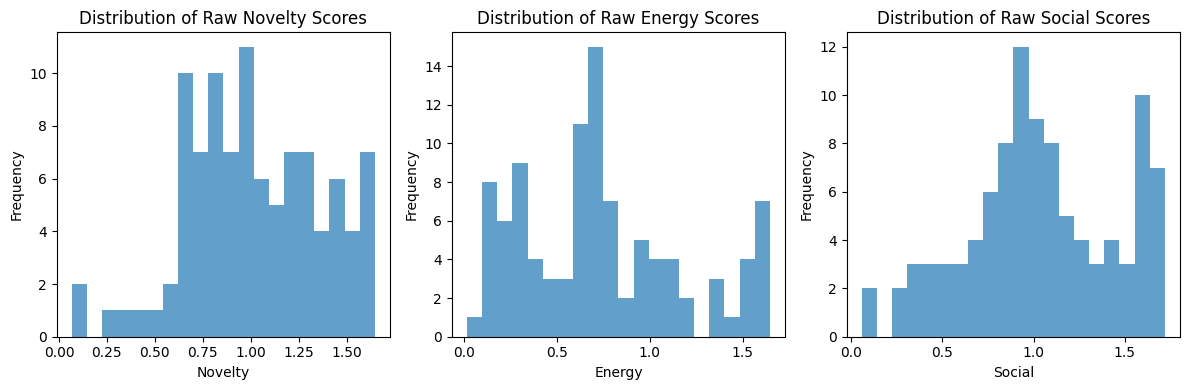

In [16]:
# import required libraries for plotting
import matplotlib.pyplot as plt

# inspect the distribution of the raw mood scores
raw_novelty = final_ab["novelty"].tolist()
raw_energy = final_ab["energy"].tolist()
raw_social = final_ab["social"].tolist()

# define parameters for binning and plotting
bins = 20
alpha = 0.7

# plot the distributions of the raw mood scores
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(raw_novelty, bins=bins, alpha=alpha)
plt.xlabel('Novelty')
plt.ylabel('Frequency')
plt.title('Distribution of Raw Novelty Scores')

plt.subplot(1, 3, 2)
plt.hist(raw_energy, bins=bins, alpha=alpha)
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Distribution of Raw Energy Scores')

plt.subplot(1, 3, 3)
plt.hist(raw_social, bins=bins, alpha=alpha)
plt.xlabel('Social')
plt.ylabel('Frequency')
plt.title('Distribution of Raw Social Scores')

plt.tight_layout()
plt.show()

In [17]:
# Define the domain columns
domains = ['energy', 'social', 'novelty']

# Transform each domain column individually based on its unique distribution
for col in domains:
    # pct=True maps raw scores to percentile ranks in [0.0, 1.0]
    final_ab[col] = final_ab[col].rank(pct=True, method='average')

In [18]:
display(sorted(set(final_ab.columns)))

['address',
 'age_restriction',
 'big_desc',
 'clean_description',
 'description',
 'energy',
 'external_url',
 'image_url',
 'indoor_outdoor',
 'is_free',
 'latitude',
 'location_link',
 'longitude',
 'novelty',
 'schedule',
 'social',
 'start_time',
 'ticket_link',
 'title',
 'venue_name']

In [19]:
# 1. Define character class matching all quotes, apostrophes, newlines, tabs, and backslashes
pattern = r"['\"’‘“”\n\r\t\\]"

# 2. Strip them out completely
final_ab["description"] = final_ab["description"].astype(str).str.replace(pattern, " ", regex=True)
final_ab["clean_description"] = final_ab["clean_description"].astype(str).str.replace(pattern, " ", regex=True)

# 3. Clean up any resulting double spaces
final_ab["description"] = final_ab["description"].str.replace(r"\s+", " ", regex=True).str.strip()
final_ab["clean_description"] = final_ab["clean_description"].str.replace(r"\s+", " ", regex=True).str.strip()

# Create SQL Formatted Version of Data

In order to import this data to the SQL table, we convert the table of rows into a string of tuples, exporting it to a TXT document for copying into the SQL query.

In [ ]:
# format the table so that each row is in the literal string form
sql_table = ""

for i, row in final_ab.iterrows():
    sql_table = sql_table + \
f"""(
'{final_ab.loc[i, "title"]}',
'{final_ab.loc[i, "venue_name"]}',
'{final_ab.loc[i, "address"]}',
{final_ab.loc[i, "latitude"]},
{final_ab.loc[i, "longitude"]},
'{final_ab.loc[i, "clean_description"]}',
{final_ab.loc[i, "is_free"]},
'{final_ab.loc[i, "schedule"]}',
{final_ab.loc[i, "energy"]},
{final_ab.loc[i, "social"]},
{final_ab.loc[i, "novelty"]},
'{final_ab.loc[i, "age_restriction"]}',
'{final_ab.loc[i, "indoor_outdoor"]}',
'{final_ab.loc[i, "external_url"]}',
'{final_ab.loc[i, "image_url"]}'
),
"""
print(i)

# adjust the string so it is completely copy/ pastable
sql_table = """
-- 1. DROP EXISTING TABLE & CLEAN UP
DROP TABLE IF EXISTS events CASCADE;

-- 2. CREATE TABLE WITH UNIFIED SCHEMA
CREATE TABLE events (
  id UUID PRIMARY KEY DEFAULT gen_random_uuid(),
  title TEXT NOT NULL,
  venue_name TEXT NOT NULL,
  address TEXT,
  latitude DOUBLE PRECISION,
  longitude DOUBLE PRECISION,
  description TEXT,
  is_free BOOL,
  schedule TEXT NOT NULL,
  
  -- Triaxial Mood Scores (Normalized 0.00 to 1.00)
  energy NUMERIC(3,2) NOT NULL CHECK (energy BETWEEN 0 AND 1),
  social NUMERIC(3,2) NOT NULL CHECK (social BETWEEN 0 AND 1),
  novelty NUMERIC(3,2) NOT NULL CHECK (novelty BETWEEN 0 AND 1),
  
  age_restriction TEXT,
  indoor_outdoor TEXT,
  external_url TEXT,
  image_url TEXT,
  created_at TIMESTAMPTZ DEFAULT NOW()
);

-- 3. ENABLE ROW LEVEL SECURITY & PERMISSIONS
ALTER TABLE events ENABLE ROW LEVEL SECURITY;

CREATE POLICY "Allow anonymous public read access to events"
ON events FOR SELECT
TO anon, authenticated
USING (true);

GRANT SELECT ON TABLE events TO anon, authenticated;

-- 4. SEED 10 DIVERSE DEMO EVENTS
INSERT INTO events (
  title,
  venue_name,
  address,
  latitude,
  longitude,
  description,
  is_free,
  schedule,
  energy,
  social,
  novelty,
  age_restriction,
  indoor_outdoor,
  external_url,
  image_url
) VALUES\n""" + \
    sql_table[:-2] + \
        ";"

98


In [21]:
# export the formatted table to a text document
with open("sql_table.txt", "w", encoding="utf-8") as file:
    file.write(sql_table)

In [22]:
# get elapsed time between this and environment set-up
elapsed = time.perf_counter() - start
print(f"Elapsed wall time: {elapsed:.2f} seconds")

Elapsed wall time: 1458.55 seconds
